Setting

In [1]:
SEARCH_BEST_ESTIMATOR_XGBOOST = True
VERBOSE = True

#XGBOOST PARAMETER
objective='rank:pairwise'
learning_rate=0.1
max_depth=6
n_estimators=200       # Aumentiamo questo valore per dare spazio all'early stopping
colsample_bytree=0.7
subsample=0.7
tree_method='hist'    # Più veloce
eval_metric='ndcg@20'   # Metrica per la validazione
random_state=42
early_stopping_rounds=150

In [2]:
import sys
sys.path.insert(0, "../My_RecSys_Course_AT_PoliMi")
import numpy as np
np.random.seed(1234)

import pandas as pd
import scipy.sparse as sps
path = "Data/data_train.csv"  # cartella da esplorare
# carica
df = pd.read_csv(path, low_memory=False)
userID_unique = df["row"].unique()
itemID_unique = df["col"].unique()
n_users = len(userID_unique)
n_items = len(itemID_unique)
data = np.ones(len(df))


URM_all = sps.csr_matrix((data, 
                          (df["row"].values, df["col"].values)),
                        shape = (n_users, n_items))


from Data_manager.split_functions.split_train_validation_random_holdout import split_train_in_two_percentage_global_sample
from Evaluation.Evaluator import EvaluatorHoldout
from Data_manager.split_functions.split_train_validation_random_holdout import split_train_in_two_percentage_user_wise
from Recommenders.Recommender_import_list import *



#URM_train_val, URM_test = split_train_in_two_percentage_global_sample(URM_all, train_percentage = 0.8)
#URM_train, URM_validation = split_train_in_two_percentage_global_sample(URM_train_val, train_percentage = 0.8)
URM_train, URM_validation = split_train_in_two_percentage_global_sample(URM_all, train_percentage = 0.8)
evaluator_validation = EvaluatorHoldout(URM_validation, cutoff_list=[20])



/opt/anaconda3/envs/RSFramework/lib/python3.9/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


Tensorflow is not available
EvaluatorHoldout: Ignoring 37 ( 0.1%) Users that have less than 1 test interactions


In [3]:
#from Recommenders.MatrixFactorization.Marco_MF_BPR_PyTorch import MF_BPR_PyTorch 

from Recommenders.MatrixFactorization.Marco_MF_BPR_PyTorch import MF_BPR_PyTorch
from Recommenders.MatrixFactorization.PyTorch.MF_MSE_PyTorch import MF_MSE_PyTorch
from Recommenders.Neural.MultVAE_PyTorch_Recommender import MultVAERecommender_PyTorch
from Recommenders.GraphBased.LightGCNRecommender import LightGCNRecommender

n_items = URM_train.shape[1]
p_dims = [252, n_items]

# Lista di configurazione con switch ON/OFF
algorithm_configs = [
    {
        "class": UserKNNCFRecommender,
        "label": "UserKNN",
        "load_model": True,
        "use": True,
        "fit_params": {'topK': 475, 'shrink': 5, 'similarity': 'cosine', 'normalize': True, 'feature_weighting': 'TF-IDF'} #0.22130051549598997
    },
    {
        "class": ItemKNNCFRecommender,
        "label": "ItemKNN",
        "load_model": True,
        "use": True,
        "fit_params": {'topK': 6, 'shrink': 125, 'similarity': 'jaccard', 'normalize': True, 'feature_weighting': 'TF-IDF'} #0.2192685676414274
    },
    {
        "class": RP3betaRecommender,
        "label": "RP3betaRecommender",
        "load_model": True,
        "use": True, 
        "fit_params": {'topK': 32, 'alpha': 1.5354226971328793, 'beta': 0.3756757967759691, 'normalize_similarity': True}  #0.2486049637145179
    },
    {
        "class": P3alphaRecommender,
        "label": "P3alpha",
        "load_model": True,
        "use": True,
        "fit_params": {'topK': 144, 'alpha': 1.7152863095489836, 'normalize_similarity': True} #0.2361672659432464
    },
    {
        "class": SLIM_BPR_Cython,
        "label": "SLIM_BPR",
        "load_model": True,
        "use": True, 
        "fit_params": {'epochs': 597, 'topK': 322, 'learning_rate': 0.07267995775964091, 'lambda_i': 7.651940663878026e-05, 'lambda_j': 0.0008278163477348147, 'symmetric': True} #0.2550437118081842
    },
    {
        "class": EASE_R_Recommender,
        "label": "EASE_R_Recommender",
        "load_model": True,
        "use": True, 
        "fit_params": {'l2_norm': 334.60181822439773, 'normalize_matrix': False, 'topK': 1000} #0.2822549018252873
    },
    {
        "class": MultiThreadSLIM_SLIMElasticNetRecommender,
        "label": "MultiThreadSLIM_SLIMElasticNetRecommender",
        "load_model": True,
        "use": True, 
        "fit_params": {'topK': 972, 'l1_ratio': 0.0001671165888065186, 'alpha': 0.003185833602582782} #0.28654878126942557
    },
    {
        "class": MF_BPR_PyTorch,
        "label": "MF_BPR_PyTorch",
        "load_model": True,
        "use": False, 
        "fit_params": {'num_factors': 141, 'learning_rate': 0.002732273917177109, 'batch_size': 256, 'lambda_reg': 2.1545713719004193e-05} #0.11098699211627468
    },
    {
        "class": MF_MSE_PyTorch,
        "label": "MF_MSE_PyTorch",
        "load_model": True,
        "use": False, 
        "fit_params": {"epochs":100, "batch_size":512}
    },  
    {
        "class": IALSRecommender,
        "label": "IALSRecommender",
        "load_model": True,
        "use": True, 
        "fit_params": {"num_factors": 50}
    },
    {
        "class": LightFMCFRecommender,
        "label": "LightFMCFRecommender",
        "load_model": True,
        "use": True, 
        "fit_params": {'n_components': 67, 'loss': 'warp', 'sgd_mode': 'adadelta', 'learning_rate': 3.1257391783478917e-06, 'item_alpha': 6.084721448115398e-05, 'user_alpha': 6.210347349694472e-05} #0.20986802421861195
    },
    {
        "class": MultVAERecommender_PyTorch,
        "label": "MultVAERecommender_PyTorch",
        "load_model": True,
        "use": True, 
        "fit_params": {'learning_rate': 0.0004999191960794948, 'l2_reg': 0.010941469935764224, 'dropout': 0.4556442393627423, 'total_anneal_steps': 103732, 'anneal_cap': 0.455538389778215, 'batch_size': 128, 'p_dims': p_dims, 'sgd_mode':'adam', 'epochs':300} #0.24612934627774993
    }
]

Training/Loading

In [4]:
other_algorithms = {}

import os

output_folder_path = "result_models_URM_TRAIN/"

# Se la cartella non esiste, creala
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)

for config in algorithm_configs:
    print("-------------------------------------------------")
    # Controllo se l'utente vuole usare questo algoritmo
    if config["use"]:
        recommender_instance = config["class"](URM_train)
        file_path = os.path.join(output_folder_path, config["label"] + ".zip")

        if config["load_model"] and os.path.exists(file_path):
            print(f"Loading model {config['label']}...")
            recommender_instance.load_model(folder_path=output_folder_path, file_name=config["label"])
            print(f"Modello {config['label']} caricato da '{file_path}'")

        else:
            # fitta
            print(f"Training {config['label']}...")
            recommender_instance.fit(**config["fit_params"])
            recommender_instance.save_model(folder_path=output_folder_path, file_name=config["label"])
            print(f"Modello {config['label']} salvato in '{output_folder_path}'")
        
        # Aggiungi al dizionario 
        other_algorithms[config["label"]] = recommender_instance

    else:
        print(f"Skipping {config['label']} (use=False)")

print(f"\nModelli pronti per XGBoost: {list(other_algorithms.keys())}")

-------------------------------------------------
Loading model UserKNN...
UserKNNCFRecommender: Loading model from file 'result_models_URM_TRAIN/UserKNN'
UserKNNCFRecommender: Loading complete
Modello UserKNN caricato da 'result_models_URM_TRAIN/UserKNN.zip'
-------------------------------------------------
Loading model ItemKNN...
ItemKNNCFRecommender: Loading model from file 'result_models_URM_TRAIN/ItemKNN'
ItemKNNCFRecommender: Loading complete
Modello ItemKNN caricato da 'result_models_URM_TRAIN/ItemKNN.zip'
-------------------------------------------------
Loading model RP3betaRecommender...
RP3betaRecommender: Loading model from file 'result_models_URM_TRAIN/RP3betaRecommender'
RP3betaRecommender: Loading complete
Modello RP3betaRecommender caricato da 'result_models_URM_TRAIN/RP3betaRecommender.zip'
-------------------------------------------------
Loading model P3alpha...
P3alphaRecommender: Loading model from file 'result_models_URM_TRAIN/P3alpha'
P3alphaRecommender: Loading

Table creation

In [40]:
import pandas as pd
from tqdm import tqdm
import scipy.sparse as sps
import numpy as np
from xgboost import XGBRanker

n_users, n_items = URM_train.shape

import pandas as pd
from tqdm import tqdm
import numpy as np

# 1. Scegli i tuoi "Generali" (modelli forti e diversi tra loro)
# Assicurati di averli già fittati su URM_train
candidate_models = [
    other_algorithms["MultVAERecommender_PyTorch"],
    other_algorithms["EASE_R_Recommender"],
    other_algorithms["MultiThreadSLIM_SLIMElasticNetRecommender"],
]

n_users, n_items = URM_train.shape
cutoff_per_model = 500  # Prendiamo i top 200 da ognuno

print("Generazione candidati ibridi...")

# Liste per costruire il DataFrame
user_ids_list = []
item_ids_list = []

for user_id in tqdm(range(n_users)):
    # Usiamo un set per evitare duplicati (se più modelli suggeriscono lo stesso item)
    current_user_candidates = set()
    
    for model in candidate_models:
        # Ottieni raccomandazioni raw (senza rimuovere seen per ora, o con remove_seen=True se preferisci)
        recs = model.recommend(user_id, cutoff=cutoff_per_model, remove_seen_flag=True)
        current_user_candidates.update(recs)
    
    # Aggiungi al dataset
    candidates_list = list(current_user_candidates)
    user_ids_list.extend([user_id] * len(candidates_list))
    item_ids_list.extend(candidates_list)

# Creazione DataFrame ottimizzata
training_dataframe = pd.DataFrame({
    "UserID": user_ids_list,
    "ItemID": item_ids_list
})

print(f"DataFrame creato con {len(training_dataframe)} righe.")
print(f"Media candidati per utente: {len(training_dataframe) / n_users:.2f}")

Generazione candidati ibridi...


100%|██████████| 27095/27095 [00:48<00:00, 561.00it/s]


DataFrame creato con 21012370 righe.
Media candidati per utente: 775.51


In [41]:
URM_validation_coo = sps.coo_matrix(URM_validation)

correct_recommendations = pd.DataFrame({"UserID": URM_validation_coo.row,
                                        "ItemID": URM_validation_coo.col})
if VERBOSE:
    correct_recommendations

In [42]:
training_dataframe = pd.merge(training_dataframe, correct_recommendations, on=['UserID','ItemID'], how='left', indicator='Exist')
if VERBOSE:
    training_dataframe

In [43]:
training_dataframe["Label"] = training_dataframe["Exist"] == "both"
training_dataframe.drop(columns = ['Exist'], inplace=True)
if VERBOSE:
    training_dataframe

In [44]:
# Snippet da eseguire dopo aver creato 'training_dataframe'
# Conta quanti item "veri" (presenti in validation) sono finiti nel tuo dataframe di training
found_items = training_dataframe[training_dataframe["Label"] == True].shape[0]
total_items_in_validation = URM_validation.nnz

recall_candidates = found_items / total_items_in_validation
print(f"Recall massima teorica del set di candidati: {recall_candidates:.4f}")

Recall massima teorica del set di candidati: 0.8677


In [10]:
training_dataframe = training_dataframe.set_index('UserID')

for user_id in tqdm(range(n_users)):  
    for rec_label, rec_instance in other_algorithms.items():
        
        item_list = training_dataframe.loc[user_id, "ItemID"].values.tolist()
        
        all_item_scores = rec_instance._compute_item_score([user_id], items_to_compute = item_list)

        training_dataframe.loc[user_id, rec_label] = all_item_scores[0, item_list] 

training_dataframe = training_dataframe.reset_index()
training_dataframe = training_dataframe.rename(columns = {"index": "UserID"})
if VERBOSE:
    training_dataframe

  0%|          | 0/27095 [00:00<?, ?it/s]/Users/edogriba/Desktop/PoliMi/IIANNOISEMESTRE/ProjectRS/Movie-Recommendation-System/../My_RecSys_Course_AT_PoliMi/Recommenders/Neural/MultVAE_PyTorch_Recommender.py:188: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1720538194305/work/aten/src/ATen/SparseCsrTensorImpl.cpp:55.)
  user_batch_tensor = torch.sparse_csr_tensor(user_batch_tensor.indptr,
100%|██████████| 27095/27095 [02:57<00:00, 152.82it/s]


In [11]:
################################################################
# Feature Engineering Avanzato Ottimizzato
################################################################
import gc
# 1. Definisci le colonne dei modelli
model_columns = list(other_algorithms.keys())

# 2. RANKING (usiamo int32 per risparmiare memoria)
for col in model_columns:
    # Calcola il rank: 1 è il migliore.
    training_dataframe[f"{col}_rank"] = training_dataframe.groupby("UserID")[col].rank(ascending=False, method='min').astype('int32')

# 3. SCORE NORMALIZZATI (Min-Max Scaling per utente)
# Questo aiuta a confrontare modelli con scale diverse (es. ItemKNN vs SLIM)
for col in model_columns:
    user_max = training_dataframe.groupby("UserID")[col].transform("max")
    user_min = training_dataframe.groupby("UserID")[col].transform("min")
    denominator = user_max - user_min
    denominator = denominator.replace(0, 1) # Evita divisione per zero
    
    # Calcolo e conversione a float32
    training_dataframe[f"{col}_norm"] = ((training_dataframe[col] - user_min) / denominator).fillna(0).astype('float32')

# 4. VOTE COUNT (Consenso tra modelli)
rank_cols = [f"{col}_rank" for col in model_columns]
# Quanti modelli hanno messo questo item in top 20?
training_dataframe["vote_count_top10"] = (training_dataframe[rank_cols] <= 10).sum(axis=1).astype('int8')
# Quanti in top 20?
training_dataframe["vote_count_top20"] = (training_dataframe[rank_cols] <= 20).sum(axis=1).astype('int8')
training_dataframe["vote_count_top30"] = (training_dataframe[rank_cols] <= 30).sum(axis=1).astype('int8')
training_dataframe["vote_count_top100"] = (training_dataframe[rank_cols] <= 100).sum(axis=1).astype('int8')


# 5. STATISTICHE SUGLI SCORE (Nuove feature potenti per XGBoost)
norm_cols = [f"{col}_norm" for col in model_columns]
# Media degli score normalizzati
training_dataframe["mean_norm_score"] = training_dataframe[norm_cols].mean(axis=1).astype('float32')
# Deviazione standard (quanto i modelli sono in disaccordo?)
training_dataframe["std_norm_score"] = training_dataframe[norm_cols].std(axis=1).fillna(0).astype('float32')
# Score massimo e minimo tra i modelli per questo item
training_dataframe["max_norm_score"] = training_dataframe[norm_cols].max(axis=1).astype('float32')
training_dataframe["min_norm_score"] = training_dataframe[norm_cols].min(axis=1).astype('float32')

# Pulizia memoria
gc.collect()
print("Nuove feature (Rank, Norm, Stats) create!")

Nuove feature (Rank, Norm, Stats) create!


In [12]:
item_popularity = np.ediff1d(sps.csc_matrix(URM_train).indptr)

training_dataframe['item_popularity'] = item_popularity[training_dataframe["ItemID"].values.astype(int)]

if VERBOSE:
    training_dataframe

In [13]:
user_popularity = np.ediff1d(sps.csr_matrix(URM_train).indptr)

training_dataframe['user_profile_len'] = user_popularity[training_dataframe["UserID"].values.astype(int)]

if VERBOSE:
    training_dataframe

In [14]:
# --- CALCOLO FEATURE MANCANTI PER IL TRAINING ---

# 1. Differenziale RP3beta - SLIM
# (Assicurati che i nomi delle colonne siano esattamente come nel tuo dataframe)
if "RP3betaRecommender_norm" in training_dataframe.columns and "SLIM_BPR_norm" in training_dataframe.columns:
    training_dataframe["diff_RP3beta_SLIM"] = (
        training_dataframe["RP3betaRecommender_norm"] - training_dataframe["SLIM_BPR_norm"]
    ).astype('float32')
else:
    print("Attenzione: Colonne RP3/SLIM non trovate per la diff.")
    training_dataframe["diff_RP3beta_SLIM"] = 0.0

# 2. Differenziale EASE - IALS (Opzionale, se utile)
if "EASE_R_Recommender_norm" in training_dataframe.columns and "IALSRecommender_norm" in training_dataframe.columns:
    training_dataframe["diff_EASE_IALS"] = (
        training_dataframe["EASE_R_Recommender_norm"] - training_dataframe["IALSRecommender_norm"]
    ).astype('float32')
else:
     training_dataframe["diff_EASE_IALS"] = 0.0

# 3. Deviazione Standard dei Rank (std_rank)
# Ricalcoliamo la lista delle colonne rank
rank_cols = [c for c in training_dataframe.columns if c.endswith("_rank")]
training_dataframe["std_rank"] = training_dataframe[rank_cols].std(axis=1).astype('float32')

print("Feature 'diff_RP3beta_SLIM' e 'std_rank' aggiunte correttameente!")

Feature 'diff_RP3beta_SLIM' e 'std_rank' aggiunte correttameente!


In [15]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

print("--- Inizio Feature Engineering Avanzato ---")

# 1. ANALISI POPOLARITÀ NEL PROFILO UTENTE
# Capire se un utente tende a interagire con item popolari o di nicchia è fondamentale per il ranking.

# Calcoliamo la popolarità di ogni item (già fatto, ma ci assicuriamo sia un array accessibile)
item_pop_array = np.ediff1d(sps.csc_matrix(URM_train).indptr)

# Calcoliamo la popolarità media/std degli item visti da ogni utente
# Usiamo URM_train per essere veloci
user_avg_pop = []
user_std_pop = []

# Ciclo rapido sugli utenti (si può ottimizzare ma per 27k utenti è veloce)
# Sfruttiamo la struttura CSR per velocità: URM_train[user_id].indices sono gli item visti
for user_id in range(n_users):
    start_pos = URM_train.indptr[user_id]
    end_pos = URM_train.indptr[user_id + 1]
    
    if end_pos > start_pos:
        indices = URM_train.indices[start_pos:end_pos]
        pops = item_pop_array[indices]
        user_avg_pop.append(np.mean(pops))
        user_std_pop.append(np.std(pops))
    else:
        user_avg_pop.append(0)
        user_std_pop.append(0)

# Aggiungiamo al DataFrame (usando un map per sicurezza)
training_dataframe['user_avg_item_pop'] = training_dataframe['UserID'].map(lambda x: user_avg_pop[x]).astype('float32')
training_dataframe['user_std_item_pop'] = training_dataframe['UserID'].map(lambda x: user_std_pop[x]).astype('float32')

# Feature di interazione: Quanto questo item è "distante" dalla "zona di comfort" dell'utente?
# Se un utente guarda solo film di nicchia (pop bassa), un item molto popolare potrebbe non piacergli.
training_dataframe['pop_ratio_user'] = (
    training_dataframe['item_popularity'] / (training_dataframe['user_avg_item_pop'] + 1)
).astype('float32')

print("Feature Profilo Utente create.")

# 2. CLUSTERING DEGLI UTENTI E POPOLARITÀ LOCALE
# Raggruppiamo gli utenti simili e vediamo se l'item è popolare *in quel gruppo*.

# A. Riduciamo la dimensionalità per fare clustering veloce (SVD su URM)
print("Calcolo SVD per clustering...")
user_factors = other_algorithms['IALSRecommender'].USER_factors

print("Esecuzione KMeans sugli embedding IALS...")
n_clusters = 10 # Puoi provare anche 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(user_factors)

# 1. Hard Clustering (L'etichetta del cluster)
user_clusters = kmeans.labels_

# 2. Soft Clustering (Distanza dai centroidi)
# Questa matrice ha shape (n_users, n_clusters)
user_distances = kmeans.transform(user_factors)
                                

# Aggiungiamo il cluster al dataframe
training_dataframe['user_cluster'] = training_dataframe['UserID'].map(lambda x: user_clusters[x]).astype('int8')
# Creiamo un dataframe temporaneo per le distanze
dist_columns = [f"dist_cluster_{i}" for i in range(n_clusters)]
dist_df = pd.DataFrame(user_distances, columns=dist_columns)
dist_df["UserID"] = range(n_users)
# Facciamo il merge con il training_dataframe
training_dataframe = training_dataframe.merge(dist_df, on="UserID", how="left")

# C. Calcolo popolarità per Cluster
# Creiamo una matrice (n_clusters x n_items) con la popolarità
print("Calcolo popolarità per cluster...")
cluster_item_pop = np.zeros((n_clusters, n_items), dtype=np.float32)

# Per farlo velocemente, iteriamo sulla URM
coo_train = URM_train.tocoo()
for u, i in zip(coo_train.row, coo_train.col):
    c = user_clusters[u]
    cluster_item_pop[c, i] += 1.0

# Normalizziamo per dimensione cluster (opzionale, ma aiuta)
for c in range(n_clusters):
    cluster_size = np.sum(user_clusters == c)
    if cluster_size > 0:
        cluster_item_pop[c, :] /= cluster_size

# D. Mappiamo la popolarità del cluster nel dataframe
# Questo richiede un po' di attenzione per farlo vettorializzato
# Usiamo i valori numpy per velocità
user_cluster_ids = training_dataframe['user_cluster'].values
item_ids = training_dataframe['ItemID'].values
# Indexing avanzato di numpy: preleva il valore dalla matrice [cluster, item]
training_dataframe['cluster_pop'] = cluster_item_pop[user_cluster_ids, item_ids]

print("Feature Clustering create.")

--- Inizio Feature Engineering Avanzato ---
Feature Profilo Utente create.
Calcolo SVD per clustering...
Esecuzione KMeans sugli embedding IALS...
Calcolo popolarità per cluster...
Feature Clustering create.


In [16]:
# --- NUOVO BLOCCO: CALCOLO PERFORMANCE (MAP) PER CLUSTER ---
# Assicurati di avere 'evaluator_validation' e 'user_clusters' (l'array delle label) disponibili

print("Calcolo delle performance dei modelli per ogni cluster...")

# 1. Creiamo un dizionario per salvare i risultati
cluster_perf_data = []
models_to_evaluate = other_algorithms # Usa il tuo dizionario di modelli caricati

for cluster_id in range(n_clusters):
    # Troviamo gli utenti che appartengono a questo cluster
    # user_clusters è l'array che hai calcolato con KMeans
    users_in_cluster = np.where(user_clusters == cluster_id)[0]
    
    # Intersezione con gli utenti del validation set
    valid_users_in_cluster = list(set(users_in_cluster) & set(evaluator_validation.users_to_evaluate))
    
    row_data = {'user_cluster': cluster_id}
    
    if len(valid_users_in_cluster) > 0:
        for name, model in models_to_evaluate.items():
            # CORREZIONE: Usiamo il metodo interno che accetta 'users_to_evaluate'
            # Nota: restituisce direttamente il dict, quindi togliamo l'unpacking ", _"
            results_dict = evaluator_validation._run_evaluation_on_selected_users(
                model, 
                users_to_evaluate=valid_users_in_cluster
            )
            # Ora results_dict è un dizionario di dizionari, quindi l'accesso è corretto
            # Extract the actual value using .result()
            map_metric_object = results_dict[20]["RECALL"]
            row_data[f'Cluster_RECALL_{name}'] = float(str(map_metric_object))
            
    else:
        # Fallback se non ci sono utenti
        for name in models_to_evaluate.keys():
            row_data[f'Cluster_RECALL_{name}'] = 0.0
            
    cluster_perf_data.append(row_data)

# 2. Creiamo il DataFrame delle performance
cluster_perf_df = pd.DataFrame(cluster_perf_data)

# 2. Assegniamo il tipo corretto alla colonna 'user_cluster' (intero)
cluster_perf_df['user_cluster'] = cluster_perf_df['user_cluster'].astype(int)

# 3. FORZIAMO TUTTE LE ALTRE COLONNE A FLOAT SUBITO
# Identifichiamo le colonne delle metriche (tutte tranne user_cluster)
metric_columns = [c for c in cluster_perf_df.columns if c != 'user_cluster']

# Questo comando dice a Pandas: "Tratta queste colonne come numeri float64, non osare pensare che siano stringhe!"
cluster_perf_df[metric_columns] = cluster_perf_df[metric_columns].astype('float64')

# 3. Uniamo queste info al training_dataframe
# Nota: Assicurati di fare questo merge DOPO aver creato 'training_dataframe' e aver aggiunto la colonna 'user_cluster'
training_dataframe = training_dataframe.merge(cluster_perf_df, on='user_cluster', how='left')

print("Tabella performance per cluster calcolata!")
display(cluster_perf_df.head())

Calcolo delle performance dei modelli per ogni cluster...
Tabella performance per cluster calcolata!


,user_cluster,Cluster_RECALL_UserKNN,Cluster_RECALL_ItemKNN,Cluster_RECALL_RP3betaRecommender,Cluster_RECALL_P3alpha,Cluster_RECALL_SLIM_BPR,Cluster_RECALL_EASE_R_Recommender,Cluster_RECALL_MultiThreadSLIM_SLIMElasticNetRecommender,Cluster_RECALL_IALSRecommender,Cluster_RECALL_LightFMCFRecommender,Cluster_RECALL_MultVAERecommender_PyTorch
0,0,457.281744,430.326030,518.487102,493.163077,518.841081,578.814670,596.130654,478.871609,224.427976,484.806722
1,1,793.862911,748.245056,858.316816,809.985638,886.246457,982.025283,1001.074061,809.931686,494.227469,830.549924
2,2,325.461481,341.224617,363.600422,338.088733,357.776755,399.440080,407.721702,337.723339,127.311030,337.073518
3,3,203.551833,199.909750,232.208956,216.477341,222.521423,258.883226,266.321211,212.207048,103.649578,222.644296
4,4,1388.947304,1359.086306,1582.661080,1478.774563,1648.074746,1811.173575,1836.076839,1413.196007,814.886547,1413.517216


In [17]:
training_dataframe = training_dataframe.sort_values("UserID").reset_index()
training_dataframe.drop(columns = ['index'], inplace=True)
training_dataframe

,UserID,ItemID,Label,UserKNN,ItemKNN,RP3betaRecommender,P3alpha,SLIM_BPR,EASE_R_Recommender,MultiThreadSLIM_SLIMElasticNetRecommender,...,Cluster_RECALL_UserKNN,Cluster_RECALL_ItemKNN,Cluster_RECALL_RP3betaRecommender,Cluster_RECALL_P3alpha,Cluster_RECALL_SLIM_BPR,Cluster_RECALL_EASE_R_Recommender,Cluster_RECALL_MultiThreadSLIM_SLIMElasticNetRecommender,Cluster_RECALL_IALSRecommender,Cluster_RECALL_LightFMCFRecommender,Cluster_RECALL_MultVAERecommender_PyTorch
0,0,2049,False,1.054805,0.047228,0.000000,0.000000,0.977939,0.052030,0.064724,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
1,0,5335,False,3.491678,0.000000,0.000000,0.000000,1.971639,0.035631,0.007478,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
2,0,5337,False,4.959803,0.171199,0.000000,0.029318,3.084800,0.175965,0.110242,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
3,0,3290,False,0.295383,0.099804,0.023571,0.009920,1.059185,-0.005766,0.046288,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
4,0,5342,False,2.023864,0.050980,0.060499,0.011829,1.871867,0.055443,0.063220,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19627419,27094,6711,False,2.113669,0.024038,0.105158,0.009648,3.351975,0.042996,0.065149,...,760.465721,755.280158,847.552987,792.826945,867.171811,955.427435,979.360488,784.531913,365.451905,785.715082
19627420,27094,573,False,3.276729,0.064885,0.102141,0.006994,2.828578,0.094204,0.114253,...,760.465721,755.280158,847.552987,792.826945,867.171811,955.427435,979.360488,784.531913,365.451905,785.715082
19627421,27094,2625,False,5.106032,0.372605,0.174722,0.027920,4.304615,0.148021,0.283415,...,760.465721,755.280158,847.552987,792.826945,867.171811,955.427435,979.360488,784.531913,365.451905,785.715082
19627422,27094,6691,True,6.008116,0.129944,0.158832,0.037898,4.180240,0.166085,0.230308,...,760.465721,755.280158,847.552987,792.826945,867.171811,955.427435,979.360488,784.531913,365.451905,785.715082


In [18]:
groups = training_dataframe.groupby("UserID").size().values
groups

array([685, 870, 702, ..., 765, 768, 693])

XGBOOST

In [19]:
from xgboost import XGBRanker
from xgboost import XGBClassifier

In [20]:
import numpy as np

# 1. Impostiamo i parametri del modello (includendo l'early stopping se non già fatto)
# Nota: n_estimators deve essere alto, ci penserà l'early stopping a fermarlo
XGB_model = XGBRanker(
    objective='rank:pairwise',
    learning_rate=0.1,
    max_depth=6,
    n_estimators=2000,       # Aumentiamo questo valore per dare spazio all'early stopping
    colsample_bytree=0.7,
    subsample=0.7,
    tree_method='hist',      # Più veloce
    eval_metric='ndcg@20',   # Metrica per la validazione
    random_state=42,
    early_stopping_rounds=150    # Si ferma se non migliora per 50 round

)

# 2. Split del training_dataframe in Train e Validation (Split per Utente)
# È fondamentale splittare per UserID per mantenere integri i gruppi di ranking
user_ids = training_dataframe['UserID'].unique()
np.random.shuffle(user_ids)

train_split_limit = int(len(user_ids) * 0.8)
train_users = user_ids[:train_split_limit]
val_users = user_ids[train_split_limit:]

# Filtriamo il dataframe
train_df = training_dataframe[training_dataframe['UserID'].isin(train_users)]
val_df = training_dataframe[training_dataframe['UserID'].isin(val_users)]

# 3. Ordinamento (Necessario per XGBRanker che usa i gruppi)
# I dati devono essere ordinati per UserID affinché il parametro 'group' funzioni
train_df = train_df.sort_values("UserID")
val_df = val_df.sort_values("UserID")

# 4. Preparazione delle matrici delle features e dei target
# Assicurati che 'features_to_use' sia definita come nel tuo codice originale (Cella 20)
features_to_use = (
    model_columns + 
    [f"{col}_rank" for col in model_columns] +
    [f"{col}_norm" for col in model_columns] +
    # ... le tue feature precedenti ...
    ["vote_count_top10", "vote_count_top20", "vote_count_top30", "vote_count_top100", 
     "mean_norm_score", "std_norm_score", "max_norm_score", "min_norm_score", 
     "item_popularity", "user_profile_len", 
     # --- NUOVE FEATURE ---
     "diff_RP3beta_SLIM", "std_rank",  # Quelle aggiunte prima
     "user_avg_item_pop", "user_std_item_pop", "pop_ratio_user", "cluster_pop", "user_cluster"] 
     + dist_columns 
     +[c for c in cluster_perf_df.columns if c != 'user_cluster']
)

print(f"Feature usate per XGBoost: {features_to_use}")


X_train = train_df[features_to_use]
y_train = train_df["Label"]
groups_train = train_df.groupby("UserID").size().values

X_val = val_df[features_to_use]
y_val = val_df["Label"]
groups_val = val_df.groupby("UserID").size().values

print(f"Training su {len(X_train)} righe ({len(groups_train)} utenti)")
print(f"Validation su {len(X_val)} righe ({len(groups_val)} utenti)")



Feature usate per XGBoost: ['UserKNN', 'ItemKNN', 'RP3betaRecommender', 'P3alpha', 'SLIM_BPR', 'EASE_R_Recommender', 'MultiThreadSLIM_SLIMElasticNetRecommender', 'IALSRecommender', 'LightFMCFRecommender', 'MultVAERecommender_PyTorch', 'UserKNN_rank', 'ItemKNN_rank', 'RP3betaRecommender_rank', 'P3alpha_rank', 'SLIM_BPR_rank', 'EASE_R_Recommender_rank', 'MultiThreadSLIM_SLIMElasticNetRecommender_rank', 'IALSRecommender_rank', 'LightFMCFRecommender_rank', 'MultVAERecommender_PyTorch_rank', 'UserKNN_norm', 'ItemKNN_norm', 'RP3betaRecommender_norm', 'P3alpha_norm', 'SLIM_BPR_norm', 'EASE_R_Recommender_norm', 'MultiThreadSLIM_SLIMElasticNetRecommender_norm', 'IALSRecommender_norm', 'LightFMCFRecommender_norm', 'MultVAERecommender_PyTorch_norm', 'vote_count_top10', 'vote_count_top20', 'vote_count_top30', 'vote_count_top100', 'mean_norm_score', 'std_norm_score', 'max_norm_score', 'min_norm_score', 'item_popularity', 'user_profile_len', 'diff_RP3beta_SLIM', 'std_rank', 'user_avg_item_pop', 'use

In [21]:
!pip install -q optuna

In [22]:
import optuna
import xgboost
from xgboost import XGBRanker

# ============================================================================
# OPTUNA HYPERPARAMETER TUNING WITH EARLY STOPPING
# ============================================================================

FIXED_PARAMS = {
    "objective": "rank:pairwise",
    "eval_metric": "ndcg@20",
    "tree_method": "hist",
    "random_state": 42,
    "max_depth": 6,
    "min_child_weight": 1.0,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
}

def objective(trial):
    params = {
        **FIXED_PARAMS,
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.15),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 3.0),
        "n_estimators": 1500,
        "early_stopping_rounds": 150 
    }
    
    model = XGBRanker(**params)
    
    model.fit(
        X_train,
        y_train,
        group=groups_train,
        eval_set=[(X_val, y_val)],
        eval_group=[groups_val],
        verbose=False  # Changed to False for cleaner Optuna output
    )
    
    # Return the best validation score
    return model.best_score

# Create Optuna study
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=3,
        n_warmup_steps=30
    )
)

# Run optimization
print("="*60)
print("STARTING OPTUNA HYPERPARAMETER OPTIMIZATION")
print("="*60)
print(f"Number of trials: 25")
print(f"Timeout: 15 hours")
print(f"Early stopping rounds: 150")
print("="*60 + "\n")

study.optimize(
    objective,
    n_trials=50,
    timeout=9 * 3600,
    show_progress_bar=True  # Add progress bar
)

[I 2026-01-07 13:14:55,464] A new study created in memory with name: no-name-a067987e-62f9-4464-aa2f-155676ab44cd


STARTING OPTUNA HYPERPARAMETER OPTIMIZATION
Number of trials: 25
Timeout: 15 hours
Early stopping rounds: 150



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-01-07 13:23:27,521] Trial 0 finished with value: 0.35299279564349956 and parameters: {'learning_rate': 0.08745401188473625, 'gamma': 0.9507143064099162, 'reg_lambda': 2.329984854528513}. Best is trial 0 with value: 0.35299279564349956.
[I 2026-01-07 13:30:06,643] Trial 1 finished with value: 0.35273656379593504 and parameters: {'learning_rate': 0.10986584841970366, 'gamma': 0.15601864044243652, 'reg_lambda': 0.8899863008405067}. Best is trial 0 with value: 0.35299279564349956.
[I 2026-01-07 13:39:06,535] Trial 2 finished with value: 0.3534104066914974 and parameters: {'learning_rate': 0.05580836121681995, 'gamma': 0.8661761457749352, 'reg_lambda': 2.002787529358022}. Best is trial 2 with value: 0.3534104066914974.
[I 2026-01-07 13:46:09,160] Trial 3 finished with value: 0.35320462251656487 and parameters: {'learning_rate': 0.12080725777960455, 'gamma': 0.020584494295802447, 'reg_lambda': 2.9247746304049858}. Best is trial 2 with value: 0.3534104066914974.
[I 2026-01-07 13:51:11

XGBOOST FINAL

In [24]:
# ESEGUIRE SOLO DOPO AVER TROVATO IL BEST_ITERATION CON IL CODICE PRECEDENTE

# 1. Recupera il numero ottimale di alberi trovato
print(f"Addestro il modello finale su TUTTI i dati con i parametri di optuna...")

# 2. Ricostruisci X e y completi (senza split)
X_all = training_dataframe[features_to_use]
y_all = training_dataframe["Label"]
groups_all = training_dataframe.groupby("UserID").size().values

# 3. Re-inizializza il modello con il numero esatto di alberi
# Nota: togliamo l'early stopping qui perché usiamo tutto il dataset
best_params = study.best_params
XGB_model_final = XGBRanker(
    objective='rank:pairwise',
    eval_metric='ndcg@20',
    tree_method='hist',
    random_state=42,
    max_depth=6,           # se lo hai fissato nei fixed params
    min_child_weight=1.0,  # fisso
    subsample=0.7,
    colsample_bytree=0.7,
    n_estimators=1500,     # o alto per permettere early stopping
    learning_rate=best_params['learning_rate'],
    gamma=best_params['gamma'],
    reg_lambda=best_params['reg_lambda'],
)

# 4. Fit finale su tutto
XGB_model_final.fit(
    X_all, 
    y_all, 
    group=groups_all,
    verbose=True
)

# Ora usa XGB_model_final per la submission invece di XGB_model
XGB_model = XGB_model_final
XGB_model.save_model("xgb_model.json")

Addestro il modello finale su TUTTI i dati con i parametri di optuna...


<Axes: title={'center': 'Weight (Frequence)'}, xlabel='F score', ylabel='Features'>

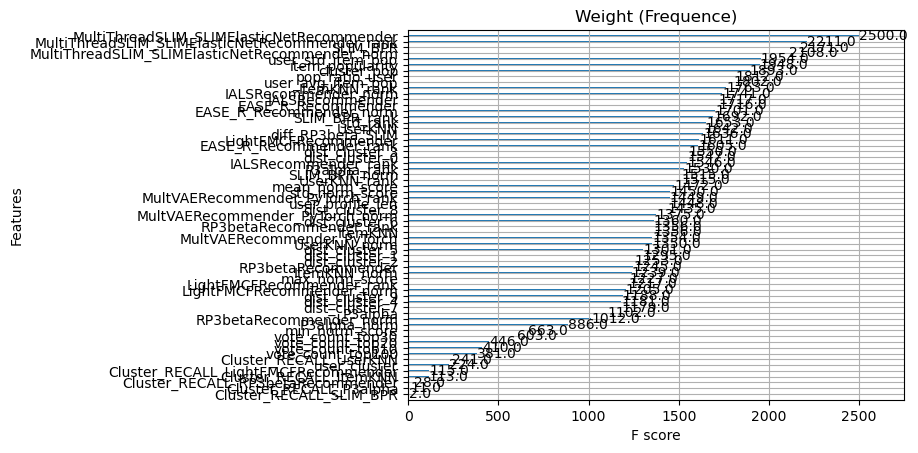

In [25]:
from xgboost import plot_importance
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequence)')

<Axes: title={'center': 'Gain'}, xlabel='F score', ylabel='Features'>

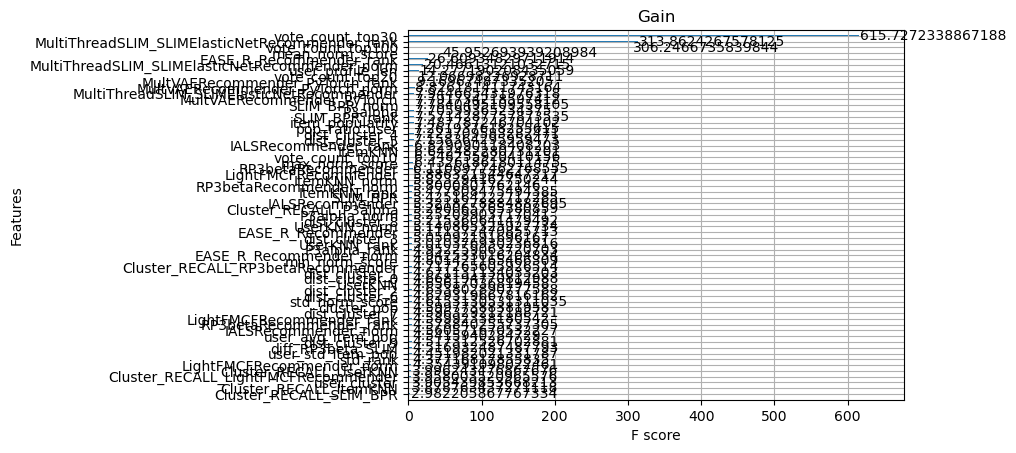

In [26]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='F score', ylabel='Features'>

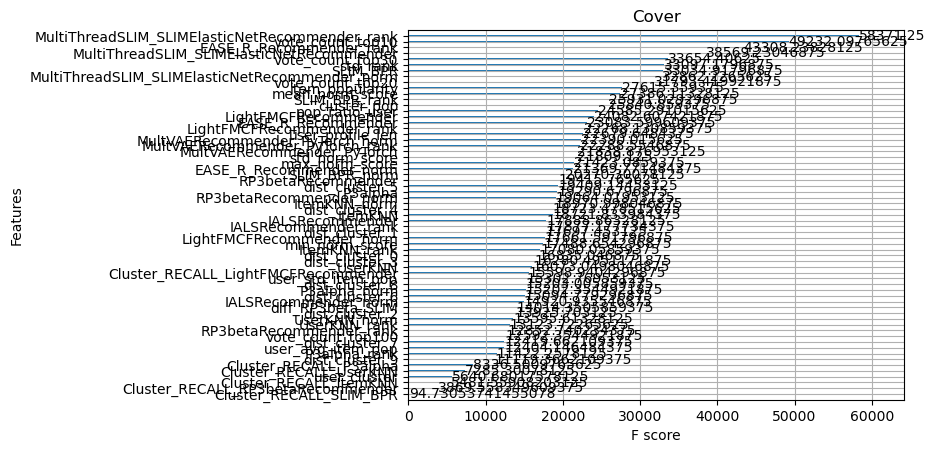

In [27]:
plot_importance(XGB_model, importance_type='cover', title='Cover')

# Retrain su tutto

In [28]:
other_algorithms_all = {}

import os

output_folder_path = "result_models_URM_ALL/"

# Se la cartella non esiste, creala
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)

for config in algorithm_configs:
    print("-------------------------------------------------")
    # Controllo se l'utente vuole usare questo algoritmo
    if config["use"]:
        recommender_instance = config["class"](URM_all)
        file_path = os.path.join(output_folder_path, config["label"] + ".zip")

        if config["load_model"] and os.path.exists(file_path):
            print(f"Loading model {config['label']}...")
            recommender_instance.load_model(folder_path=output_folder_path, file_name=config["label"])
            print(f"Modello {config['label']} caricato da '{file_path}'")

        else:
            # fitta
            print(f"Training {config['label']}...")
            recommender_instance.fit(**config["fit_params"])
            recommender_instance.save_model(folder_path=output_folder_path, file_name=config["label"])
            print(f"Modello {config['label']} salvato in '{output_folder_path}'")
        
        # Aggiungi al dizionario 
        other_algorithms_all[config["label"]] = recommender_instance

    else:
        print(f"Skipping {config['label']} (use=False)")

print(f"\nModelli pronti per XGBoost: {list(other_algorithms_all.keys())}")

-------------------------------------------------
Loading model UserKNN...
UserKNNCFRecommender: Loading model from file 'result_models_URM_ALL/UserKNN'
UserKNNCFRecommender: Loading complete
Modello UserKNN caricato da 'result_models_URM_ALL/UserKNN.zip'
-------------------------------------------------
Loading model ItemKNN...
ItemKNNCFRecommender: Loading model from file 'result_models_URM_ALL/ItemKNN'
ItemKNNCFRecommender: Loading complete
Modello ItemKNN caricato da 'result_models_URM_ALL/ItemKNN.zip'
-------------------------------------------------
Loading model RP3betaRecommender...
RP3betaRecommender: Loading model from file 'result_models_URM_ALL/RP3betaRecommender'
RP3betaRecommender: Loading complete
Modello RP3betaRecommender caricato da 'result_models_URM_ALL/RP3betaRecommender.zip'
-------------------------------------------------
Loading model P3alpha...
P3alphaRecommender: Loading model from file 'result_models_URM_ALL/P3alpha'
P3alphaRecommender: Loading complete
Mode

In [45]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import gc

# --- CONFIGURAZIONE BATCH ---
BATCH_SIZE = 1000  # Numero di utenti da processare alla volta
target_users = pd.read_csv("Data/data_target_users_test.csv")["user_id"].values
n_target_users = len(target_users)
submission = []

# Modelli candidati (assicurati siano già addestrati su tutto)
candidate_models_for_test = [
    other_algorithms_all["MultVAERecommender_PyTorch"],
    other_algorithms_all["EASE_R_Recommender"],
    other_algorithms_all["MultiThreadSLIM_SLIMElasticNetRecommender"],
]
cutoff_candidates = 500 

print(f"Inizio predizione per {n_target_users} utenti in batch da {BATCH_SIZE}...")

# --- CICLO SUI BATCH DI UTENTI ---
for start_idx in range(0, n_target_users, BATCH_SIZE):
    end_idx = min(start_idx + BATCH_SIZE, n_target_users)
    batch_users = target_users[start_idx:end_idx]
    
    # 1. Generazione Candidati per il Batch
    users_test_list = []
    items_test_list = []
    
    for user_id in batch_users:
        candidates = set()
        for model in candidate_models_for_test:
            # remove_seen=True è fondamentale qui!
            recs = model.recommend(user_id, cutoff=cutoff_candidates, remove_seen_flag=True)
            candidates.update(recs)
        
        users_test_list.extend([user_id] * len(candidates))
        items_test_list.extend(list(candidates))
    
    # Creazione DataFrame temporaneo per il batch
    batch_df = pd.DataFrame({
        "UserID": users_test_list,
        "ItemID": items_test_list
    })
    
    # 2. Feature Engineering sul Batch (Veloce perché vettorizzato)
    
    # A. Score dei modelli base
    # Inizializziamo le colonne
    for model_name, model_obj in other_algorithms_all.items():
        batch_df[model_name] = 0.0 
        
    # Riempiamo gli score iterando sugli utenti unici del batch
    for u in batch_users:
        # Indici delle righe di questo utente nel batch corrente
        user_mask = (batch_df["UserID"] == u)
        user_items = batch_df.loc[user_mask, "ItemID"].values.astype(int)
        
        if len(user_items) == 0: continue
        
        for model_name, model_obj in other_algorithms_all.items():
             # Calcolo score
             s = model_obj._compute_item_score([u], items_to_compute=user_items)
             
             # Gestione output score (vettoriale vs matrice)
             if s.shape[1] == len(user_items):
                 values_to_assign = s.flatten()
             else:
                 values_to_assign = s[0, user_items]
            
             batch_df.loc[user_mask, model_name] = values_to_assign

    # B. Altre Feature (Rank, Norm, etc)
    for col in model_columns:
        batch_df[f"{col}_rank"] = batch_df.groupby("UserID")[col].rank(ascending=False, method='min')
        
        user_max = batch_df.groupby("UserID")[col].transform("max")
        user_min = batch_df.groupby("UserID")[col].transform("min")
        denom = user_max - user_min
        denom = denom.replace(0, 1)
        batch_df[f"{col}_norm"] = ((batch_df[col] - user_min) / denom).fillna(0)

    # Vote Counts & Stats
    rank_cols = [f"{col}_rank" for col in model_columns]
    batch_df["vote_count_top10"] = (batch_df[rank_cols] <= 10).sum(axis=1)
    batch_df["vote_count_top20"] = (batch_df[rank_cols] <= 20).sum(axis=1)
    batch_df["vote_count_top30"] = (batch_df[rank_cols] <= 30).sum(axis=1)
    batch_df["vote_count_top100"] = (batch_df[rank_cols] <= 100).sum(axis=1)
    
    norm_cols = [f"{col}_norm" for col in model_columns]
    batch_df["mean_norm_score"] = batch_df[norm_cols].mean(axis=1)
    batch_df["std_norm_score"] = batch_df[norm_cols].std(axis=1).fillna(0)
    batch_df["max_norm_score"] = batch_df[norm_cols].max(axis=1)
    batch_df["min_norm_score"] = batch_df[norm_cols].min(axis=1)

    # C. Feature Avanzate (Popolarità, Cluster Base)
    batch_df['item_popularity'] = item_pop_array[batch_df["ItemID"].values.astype(int)]
    batch_df['user_profile_len'] = user_popularity[batch_df["UserID"].values.astype(int)]
    
    batch_df['user_avg_item_pop'] = batch_df['UserID'].map(lambda x: user_avg_pop[x])
    batch_df['user_std_item_pop'] = batch_df['UserID'].map(lambda x: user_std_pop[x])
    batch_df['pop_ratio_user'] = batch_df['item_popularity'] / (batch_df['user_avg_item_pop'] + 1)
    
    u_cluster_ids = batch_df['UserID'].map(lambda x: user_clusters[x]).values
    batch_df['user_cluster'] = u_cluster_ids
    i_ids = batch_df['ItemID'].values
    batch_df['cluster_pop'] = cluster_item_pop[u_cluster_ids, i_ids]
    
    # D. Differenziali
    batch_df["diff_RP3beta_SLIM"] = batch_df["RP3betaRecommender_norm"] - batch_df["SLIM_BPR_norm"]
    if "EASE_R_Recommender_norm" in batch_df.columns:
        batch_df["diff_EASE_IALS"] = batch_df["EASE_R_Recommender_norm"] - batch_df["IALSRecommender_norm"]
    batch_df["std_rank"] = batch_df[rank_cols].std(axis=1)

    # --- AGGIUNTA IMPORTANTE: Feature mancanti per XGBoost ---
    
    # 1. Distanze dai Cluster (dist_cluster_X)
    # Recuperiamo le distanze pre-calcolate in user_distances
    u_ids_batch = batch_df['UserID'].values.astype(int)
    batch_dists = user_distances[u_ids_batch] 
    for i in range(n_clusters):
        batch_df[f"dist_cluster_{i}"] = batch_dists[:, i]
        
    # 2. Performance per Cluster (MAP/RECALL)
    # Uniamo il dataframe cluster_perf_df (creato nel blocco precedente)
    batch_df = batch_df.merge(cluster_perf_df, on='user_cluster', how='left')
    
    # --------------------------------------------------------

    # 3. Predizione XGBoost
    # Selezioniamo le feature nell'ordine esatto del training
    X_batch = batch_df[features_to_use]
    batch_df["xgb_score"] = XGB_model.predict(X_batch)
    
    # 4. Selezione Top 10 e salvataggio
    for user_id in batch_users:
        user_recs = batch_df[batch_df["UserID"] == user_id]
        user_recs = user_recs.sort_values("xgb_score", ascending=False)
        top_20 = user_recs["ItemID"].head(20).values
        submission.append((user_id, " ".join(map(str, top_20))))
        
    # Pulizia memoria
    del batch_df, X_batch
    gc.collect()
    
    print(f"Batch completato: {end_idx}/{n_target_users}", end="\r")

# Scrittura file finale
submission_df = pd.DataFrame(submission, columns=["user_id", "item_list"])
submission_df.to_csv("submission_xgboost_batched.csv", index=False)
print("\nFatto! File salvato: submission_xgboost_batched.csv")

Inizio predizione per 27095 utenti in batch da 1000...
Batch completato: 27095/27095
Fatto! File salvato: submission_xgboost_batched.csv
